
# Post-calibration diagnostics: fit quality + solver health

Loads a saved `calibration_result.json` (from `scripts/run_calibration.py`),
re-simulates the model at the fitted parameters, and plots the three curves
that matter for judging fit quality on one axis:

1. **Observed** weekly case counts (Project Tycho, `case_count`)
2. **Reporting-scaled modeled incidence** — `reporting_rate * true modeled
   incidence` — this is the curve the loss function actually compares
   against (1), so this is the honest "did the fit work" line.
3. **True modeled incidence** (unscaled) — shown alongside so it's visually
   obvious how much of the gap between "true epidemic size" and "what got
   reported" the fixed `reporting_rate` is accounting for.

Followed by a battery of post-run checks: optimizer convergence and
boundary behavior, residual diagnostics, solver-health checks (the eval-
density issue found in the burn-in solver comparison — the same failure
mode can hide in the fit window too), demographic sanity, and a
periodicity check that speaks directly to the original biennial-vs-annual
question.

**Before running**: fill in `EXPERIMENT_NAME`/`RESULT_PATH` below, and —
important — `BURN_IN_YEARS`. The saved JSON does not currently persist
`burn_in_years` (see the "gaps in the saved result" note in the last
section), so this must match whatever `--burn-in-years` the run actually
used or the re-simulated initial conditions won't match what the optimizer
actually scored.


In [49]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from scipy.signal import find_peaks

from src import config, model, calibration, contact_matrix, historical_population as hpop
from src import data  # project's own Tycho-loading module

pd.set_option("display.width", 140)


In [50]:

RESULT_PATH = config.DATA_PROCESSED_DIR / "calibration_result.json"

# MUST match the --burn-in-years the saved run actually used -- not
# recoverable from the JSON itself (see the note at the end of this
# notebook). If the run used --initial-conditions-json / no burn-in
# folding at all, set this to 0 and BURN_IN_SEED_* below are unused.
BURN_IN_YEARS = 20.0
BURN_IN_SEED_INFECTED_PER_GROUP = 1.0
BURN_IN_SEED_GROUP_INDEX = 0
BURN_IN_N_POINTS = 200

with open(RESULT_PATH) as f:
    saved = json.load(f)

print(f"Loaded {RESULT_PATH}")
print(f"  fit window: {saved['fit_window']['start']} .. {saved['fit_window']['end']}")
print(f"  converged: {saved['converged']}  (n_iterations_run={saved['n_iterations_run']})")
print(f"  beta_0={saved['beta_0']:.4f}  beta_1={saved['beta_1']:.4f}  phi={saved['phi']:.4f}")
print(f"  R0 = beta_0/gamma = {saved['beta_0'] / saved['gamma_fixed']:.3f}")
print(f"  reporting_rate = {saved['reporting_rate_fixed']:.4f}")
print(f"  fitted_at_utc: {saved['fitted_at_utc']}")


Loaded /Users/camdenwright/Documents/VSCode/Python/Personal Projects/delayed-vaccination/data/processed/calibration_result.json
  fit window: 1954-01-01 .. 1960-01-01
  converged: True  (n_iterations_run=9)
  beta_0=650.0034  beta_1=0.3000  phi=0.0001
  R0 = beta_0/gamma = 14.237
  reporting_rate = 0.1569
  fitted_at_utc: 2026-08-17T01:55:34.819468Z



## 1. Reconstruct exactly what the optimizer scored

Rebuild the full parameter dict and initial conditions the same way
`run_calibration.py` did — same vital-rate functions, same contact matrix,
same burn-in re-derivation `calibrate_beta` performs at its winning point
(see `calibration.calibrate_beta`'s "Re-running burn-in at winning
parameters" step). Getting this wrong (e.g. a different `BURN_IN_YEARS`)
silently produces a plausible-looking but *not actually representative*
plot below — this is the single most important thing to get right in this
notebook.


In [51]:

fit_start_year = pd.Timestamp(saved["fit_window"]["start"]).year
fit_end_year = pd.Timestamp(saved["fit_window"]["end"]).year

contact_matrix_df = contact_matrix.load_processed_contact_matrix()
contact_matrix_array = contact_matrix_df.to_numpy()

birth_rate_fn, death_rate_fn = hpop.build_vital_rate_functions()
birth_rate_of_t = lambda t: birth_rate_fn(fit_start_year + t)
death_rate_of_t = lambda t: death_rate_fn(fit_start_year + t)

fitted_parameters = calibration.build_full_parameters(
    saved["beta_0"], saved["beta_1"], saved["phi"],
    saved["gamma_fixed"], birth_rate_of_t, death_rate_of_t,
    contact_matrix_array,
    fixed_sigma=saved["sigma_fixed"],
    fixed_maternal_waning_rate=saved["maternal_waning_rate_fixed"],
)
fitted_parameters["vaccination_rates"] = np.asarray(saved["vaccination_rates"], dtype=float)
reporting_rate = saved["reporting_rate_fixed"]

if BURN_IN_YEARS and BURN_IN_YEARS > 0:
    print(f"Re-deriving initial conditions via {BURN_IN_YEARS:.1f}yr burn-in at the fitted parameters...")
    initial_conditions = hpop.initial_conditions_with_burn_in(
        fit_start_year=fit_start_year,
        burn_in_years=BURN_IN_YEARS,
        contact_matrix_array=contact_matrix_array,
        burn_in_beta_0=saved["beta_0"],
        burn_in_beta_1=saved["beta_1"],
        burn_in_phi=saved["phi"],
        burn_in_gamma=saved["gamma_fixed"],
        burn_in_sigma=saved["sigma_fixed"],
        burn_in_maternal_waning_rate=saved["maternal_waning_rate_fixed"],
        seed_infected_per_group=BURN_IN_SEED_INFECTED_PER_GROUP,
        seed_group_index=BURN_IN_SEED_GROUP_INDEX,
        n_burn_in_points=BURN_IN_N_POINTS,
    )
else:
    target_population = hpop.population_for_year(fit_start_year)
    print(f"No burn-in ({BURN_IN_YEARS=}) -- seeding directly at {fit_start_year} population ({target_population:,.0f}).")
    initial_conditions = hpop.initial_conditions_for_population(target_population)

burn_in_total = sum(initial_conditions[k].sum() for k in ("M0", "S0", "E0", "I0", "R0"))
print(f"Initial condition total population: {burn_in_total:,.0f}")


Re-deriving initial conditions via 20.0yr burn-in at the fitted parameters...
Initial condition total population: 8,410,336



## 2. Load observed data and re-simulate over the fit window


In [52]:

full_series = data.load_processed_series()
start, end = saved["fit_window"]["start"], saved["fit_window"]["end"]
mask = (full_series["period_start"] >= pd.Timestamp(start)) & (full_series["period_start"] < pd.Timestamp(end))
windowed_series = full_series.loc[mask].reset_index(drop=True)
assert len(windowed_series) == saved["n_observations"], (
    f"windowed series has {len(windowed_series)} rows but the saved result "
    f"says {saved['n_observations']} -- check RESULT_PATH/start/end match "
    "the actual saved run, not a different processed-data snapshot."
)

observed_times = data.series_to_elapsed_years(windowed_series)
observed_case_counts = windowed_series["case_count"].to_numpy()
observed_dates = windowed_series["period_start"].to_numpy()

# Instrument the rhs eval count directly (rather than trusting solve_ivp's
# own bookkeeping) so the solver-health check in section 4 below is a real
# count of this specific run, not an assumption.
_eval_count = [0]
_orig_ode_system = model.ode_system
def _counting_ode_system(t, y, p):
    _eval_count[0] += 1
    return _orig_ode_system(t, y, p)
model.ode_system = _counting_ode_system
try:
    interval_ends, modeled_true_incidence, modeled_true_incidence_per_age = calibration.weekly_modeled_incidence(
        fitted_parameters, initial_conditions, observed_times,
    )
finally:
    model.ode_system = _orig_ode_system

modeled_scaled_incidence = reporting_rate * modeled_true_incidence
n_rhs_evals_fit_window = _eval_count[0]

print(f"Modeled {len(modeled_true_incidence)} weekly intervals over the fit window.")
print(f"rhs evals for this integration: {n_rhs_evals_fit_window}")


Modeled 312 weekly intervals over the fit window.
rhs evals for this integration: 1298



## 3. The plot

Observed vs. reporting-scaled modeled (what the loss function sees) vs.
true modeled (the unscaled epidemic size the model thinks actually
occurred). All on elapsed-years-since-window-start x-axis converted back
to calendar dates for readability.


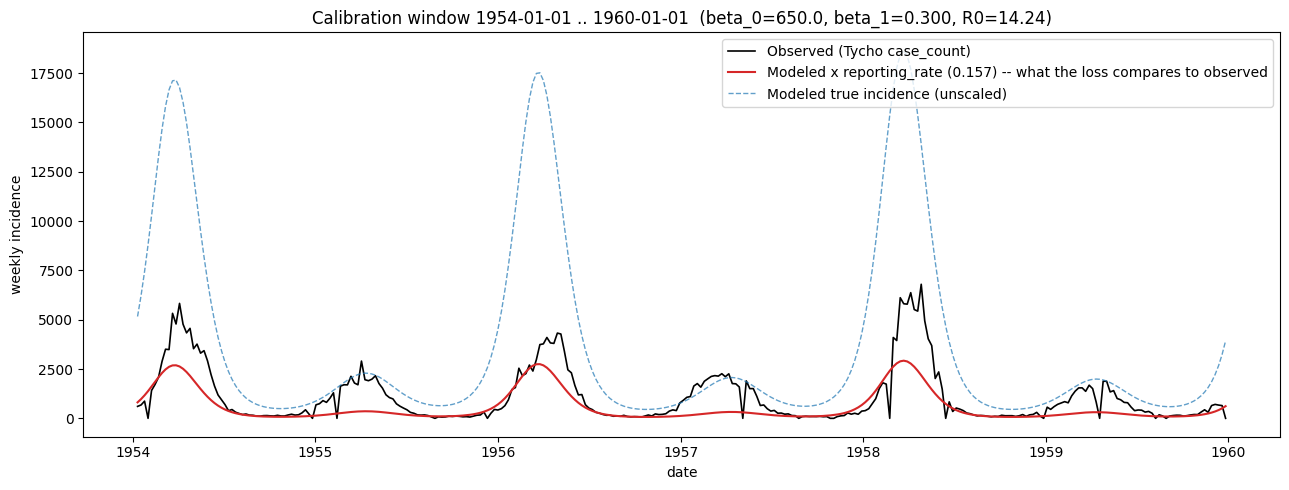

In [53]:

plot_dates = observed_dates[1:]  # weekly_modeled_incidence drops the first point (see its docstring)
observed_for_plot = observed_case_counts[1:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(plot_dates, observed_for_plot, color="black", lw=1.2, label="Observed (Tycho case_count)")
ax.plot(plot_dates, modeled_scaled_incidence, color="tab:red", lw=1.5,
        label=f"Modeled x reporting_rate ({reporting_rate:.3f}) -- what the loss compares to observed")
ax.plot(plot_dates, modeled_true_incidence, color="tab:blue", lw=1.0, ls="--", alpha=0.7,
        label="Modeled true incidence (unscaled)")
ax.set_xlabel("date")
ax.set_ylabel("weekly incidence")
ax.set_title(f"Calibration window {start} .. {end}  (beta_0={saved['beta_0']:.1f}, "
             f"beta_1={saved['beta_1']:.3f}, R0={saved['beta_0']/saved['gamma_fixed']:.2f})")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
plt.tight_layout()
plt.show()



## 4. Post-run checks

### 4a. Solver health (eval density)

The burn-in solver comparison found that a "successful" integration can
still be silently under-resolved -- a solver satisfying a loose tolerance
in very few steps, skating over real dynamics rather than resolving them.
Apply the same sanity check here to the *fit-window* integration (not just
burn-in): with `BURN_IN_N_POINTS` output points and weekly output points
in the fit window, a healthy LSODA+analytic-Jacobian run should need
several times more rhs evaluations than output points, not roughly one
per point.


In [54]:

n_output_points = len(observed_times)
eval_density = n_rhs_evals_fit_window / n_output_points
print(f"rhs evals: {n_rhs_evals_fit_window}  /  output points: {n_output_points}  "
      f"=  {eval_density:.1f} evals per output point")
if eval_density < 3:
    print("  ⚠ LOW eval density -- this looks like the same under-resolution failure "
          "mode found in the burn-in solver comparison (large steps satisfying atol "
          "on big compartments while skating over E/I). Don't trust this fit without "
          "investigating further (e.g. tighten atol/rtol and confirm the curve above "
          "doesn't change).")
else:
    print("  OK -- eval density looks like genuine step-by-step resolution, not a "
          "single-step-per-output artifact.")


rhs evals: 1298  /  output points: 313  =  4.1 evals per output point
  OK -- eval density looks like genuine step-by-step resolution, not a single-step-per-output artifact.



### 4b. Convergence and parameter-boundary check

`converged=False`, or a fitted parameter sitting at (or very near) its
configured bound, both mean the reported optimum may not be a genuine
interior optimum -- e.g. `beta_1` pinned at its upper bound would mean the
optimizer wants *even more* seasonal forcing than allowed, which is a
substantive finding worth flagging, not silently accepting.


In [55]:

print(f"converged: {saved['converged']}")
print(f"n_iterations_run: {saved['n_iterations_run']}")

bound_pad = 1e-3  # relative distance-to-bound considered "at the boundary"
for name, value in [("beta_0", saved["beta_0"]), ("beta_1", saved["beta_1"]), ("phi", saved["phi"])]:
    lo, hi = config.PARAMETER_BOUNDS[name]
    flags = []
    if lo is not None and abs(value - lo) <= bound_pad * max(abs(lo), 1.0):
        flags.append(f"AT LOWER BOUND ({lo})")
    if hi is not None and abs(value - hi) <= bound_pad * max(abs(hi), 1.0):
        flags.append(f"AT UPPER BOUND ({hi})")
    status = " ⚠ " + ", ".join(flags) if flags else "  interior"
    print(f"  {name:>8s} = {value:>10.5f}   bounds=({lo}, {hi}){status}")


converged: True
n_iterations_run: 9
    beta_0 =  650.00344   bounds=(547.875, 821.8125)  interior
    beta_1 =    0.30001   bounds=(0.0, 0.999)  interior
       phi =    0.00012   bounds=(0.0, 6.283185307179586) ⚠ AT LOWER BOUND (0.0)



### 4c. Residual diagnostics

Recompute the exact residuals the optimizer scored (signed square-root
Poisson deviance -- see `calibration._poisson_deviance_residual`) and look
for structure. A good fit has residuals with no obvious trend and no
systematic relationship to the modeled mean; a residual pattern that
tracks epidemic peaks (e.g. consistently under- or over-shooting at highs)
means the model shape is wrong in a way the optimizer couldn't fix within
[beta_0, beta_1, phi] alone.


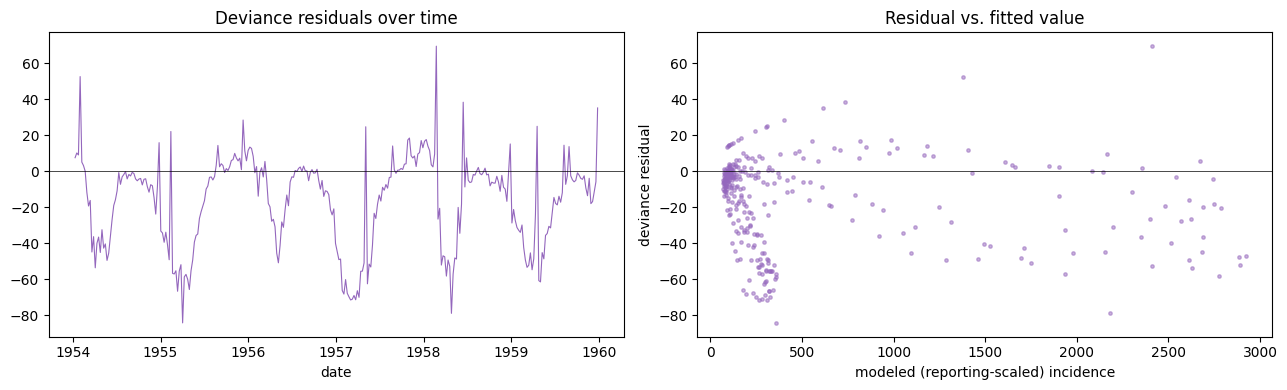

mean residual: -16.5645  (should be near 0 for a well-specified model)
residual std:  24.9457   (should be near 1 if Poisson variance is well-calibrated;
                                        notably >1 suggests overdispersion -- see calibration.py's
                                        module docstring on negative-binomial as the next step)


In [56]:

residuals = calibration._poisson_deviance_residual(modeled_scaled_incidence, observed_for_plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(plot_dates, residuals, color="tab:purple", lw=0.8)
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("Deviance residuals over time")
axes[0].set_xlabel("date")
axes[0].xaxis.set_major_formatter(DateFormatter("%Y"))

axes[1].scatter(modeled_scaled_incidence, residuals, s=6, alpha=0.5, color="tab:purple")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_xlabel("modeled (reporting-scaled) incidence")
axes[1].set_ylabel("deviance residual")
axes[1].set_title("Residual vs. fitted value")
plt.tight_layout()
plt.show()

print(f"mean residual: {residuals.mean():.4f}  (should be near 0 for a well-specified model)")
print(f"residual std:  {residuals.std():.4f}   (should be near 1 if Poisson variance is well-calibrated;")
print(f"                                        notably >1 suggests overdispersion -- see calibration.py's")
print(f"                                        module docstring on negative-binomial as the next step)")



### 4d. Local identifiability / Jacobian condition number

Recompute a finite-difference Jacobian of the residual vector at the
fitted point (same idea as `calibration.rigorous_least_squares`'s internal
diagnostic, reconstructed here since the saved JSON doesn't persist it).
A very large condition number means at least one direction in
[beta_0, beta_1, phi] is poorly constrained by this data -- consistent
with the module docstring's point that beta/gamma (and here, potentially
beta_0/beta_1) can trade off along a ridge.


In [57]:
def _residual_at(free_vec):
    beta_0, beta_1, phi = free_vec
    params = calibration.build_full_parameters(
        beta_0, beta_1, phi, saved["gamma_fixed"], birth_rate_of_t, death_rate_of_t,
        contact_matrix_array, fixed_sigma=saved["sigma_fixed"],
        fixed_maternal_waning_rate=saved["maternal_waning_rate_fixed"],
    )
    _, modeled_true, _ = calibration.weekly_modeled_incidence(
        params, initial_conditions, observed_times
    )
    modeled_scaled = reporting_rate * modeled_true
    return calibration._poisson_deviance_residual(
        modeled_scaled, observed_for_plot
    )


def finite_difference_jacobian(fun, x, bounds, rel_step=1e-6):
    """Forward finite-difference Jacobian, respecting parameter bounds."""
    x = np.asarray(x, dtype=float)
    lo, hi = np.asarray(bounds[0], dtype=float), np.asarray(bounds[1], dtype=float)

    f0 = np.asarray(fun(x), dtype=float)
    J = np.empty((f0.size, x.size), dtype=float)

    for j in range(x.size):
        # Scale the step to the parameter magnitude.
        h = rel_step * max(1.0, abs(x[j]))

        # Prefer a forward step, but stay inside the bounds.
        h = min(h, hi[j] - x[j])

        # If we're at/near the upper bound, use a backward step.
        if h <= 0:
            h = min(rel_step * max(1.0, abs(x[j])), x[j] - lo[j])
            if h <= 0:
                raise ValueError(f"Cannot perturb parameter {j} within bounds.")

            x_perturbed = x.copy()
            x_perturbed[j] -= h
            J[:, j] = (f0 - np.asarray(fun(x_perturbed), dtype=float)) / h
        else:
            x_perturbed = x.copy()
            x_perturbed[j] += h
            J[:, j] = (
                np.asarray(fun(x_perturbed), dtype=float) - f0
            ) / h

    return J


x_star = np.array([saved["beta_0"], saved["beta_1"], saved["phi"]])
lo, hi = calibration.seasonal_beta_bounds()

J = finite_difference_jacobian(
    _residual_at,
    x_star,
    bounds=(lo, hi),
    rel_step=1e-6,
)

singular_values = np.linalg.svd(J, compute_uv=False)
condition_number = (
    singular_values[0] / singular_values[-1]
    if singular_values[-1] > 0
    else np.inf
)

print("Jacobian singular values:", np.array2string(singular_values, precision=3))
print(f"condition number: {condition_number:.2e}")

if condition_number > 1e4:
    print(
        "  ⚠ HIGH condition number -- at least one parameter direction is weakly "
        "identified by this data/window. Consider a narrower fit window, a longer "
        "one, or fixing an additional parameter, per calibration.py's identifiability discussion."
    )

Jacobian singular values: [1675.473  605.764    2.081]
condition number: 8.05e+02



### 4e. Demographic sanity over the fit window

The fit window is only ~10 years typically, but the population is still
open (births/deaths/aging) -- check that total population and
age-structure stay plausible across it, not just at t=0.


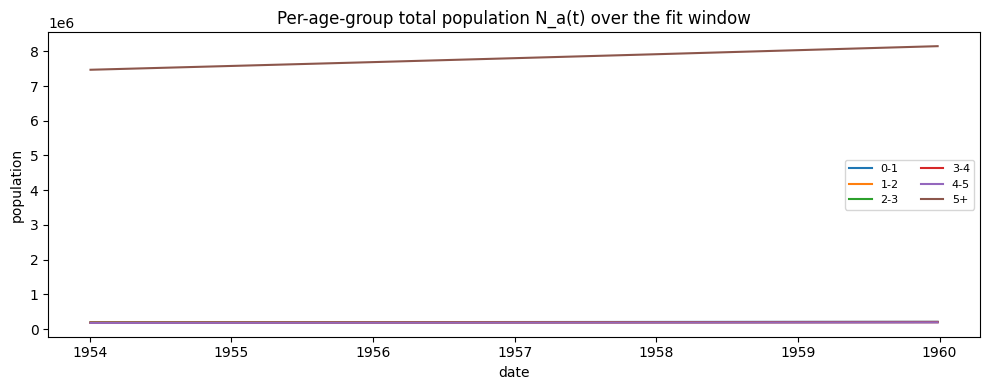

modeled total population: start=8,410,336  end=9,165,675
census-interpolated:      start=8,410,336  end=9,579,677
drift from census by window end: -4.32%


In [58]:

sim = model.simulate_model(fitted_parameters, initial_conditions, observed_times)
fig, ax = plt.subplots(figsize=(10, 4))
for a, label in enumerate(config.AGE_GROUP_LABELS):
    ax.plot(observed_dates, sim.N[:, a], label=label)
ax.set_title("Per-age-group total population N_a(t) over the fit window")
ax.set_xlabel("date")
ax.set_ylabel("population")
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
plt.tight_layout()
plt.show()

total_pop_start, total_pop_end = sim.N[0].sum(), sim.N[-1].sum()
census_start = hpop.population_for_year(pd.Timestamp(start).year)
census_end = hpop.population_for_year(pd.Timestamp(end).year)
print(f"modeled total population: start={total_pop_start:,.0f}  end={total_pop_end:,.0f}")
print(f"census-interpolated:      start={census_start:,.0f}  end={census_end:,.0f}")
print(f"drift from census by window end: {(total_pop_end - census_end) / census_end:+.2%}")



### 4f. Periodicity check -- annual vs. biennial

The question this whole project is actually trying to answer. Find peaks
in the modeled true incidence and look at the spacing between them: ~1.0
year spacing is a purely annual cycle (the seasonal forcing period
itself); ~2.0 year spacing (alternating a large peak and a small peak,
i.e. a genuine period-2 subharmonic) is the biennial signature the model
was extended (M/E compartments, see model.py's module docstring) to try
to produce.


peak times (years since window start): [0.23 1.26 2.22 3.28 4.22 5.27]
peak-to-peak spacings (years): [1.035 0.958 1.054 0.939 1.054]
mean spacing: 1.008 years
  -> looks purely ANNUAL (period ~1 year, i.e. the forcing period itself, no subharmonic resonance)


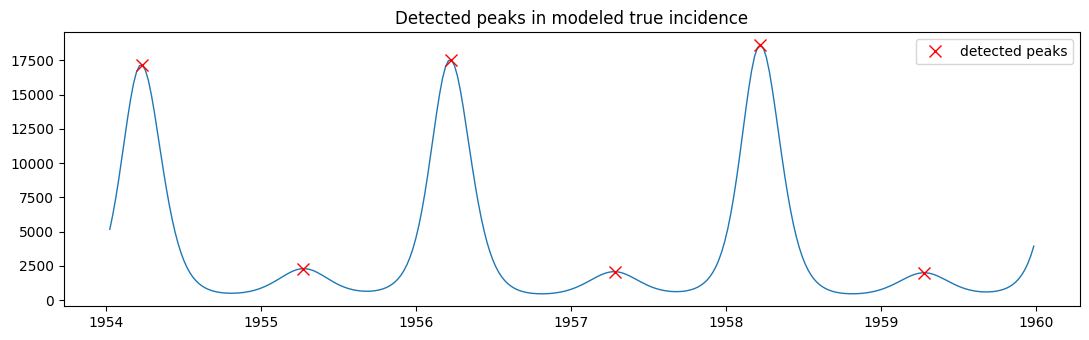

In [59]:

# `distance` in units of index count -- observed_times spacing is roughly
# weekly, so ~26 weeks (half a year) as a minimum peak separation avoids
# picking up sub-annual noise as a separate "peak."
approx_points_per_year = len(observed_times) / (observed_times[-1] - observed_times[0])
peak_idx, _ = find_peaks(modeled_true_incidence, distance=max(int(approx_points_per_year * 0.4), 1))
peak_times = observed_times[1:][peak_idx]  # offset by 1 to match modeled_true_incidence's index base

if len(peak_times) < 2:
    print(f"Only {len(peak_times)} peak(s) found in the fit window -- window may be too "
          "short to characterize periodicity; widen the fit window or inspect the burn-in "
          "trajectory instead.")
else:
    spacings = np.diff(peak_times)
    print(f"peak times (years since window start): {np.array2string(peak_times, precision=2)}")
    print(f"peak-to-peak spacings (years): {np.array2string(spacings, precision=3)}")
    print(f"mean spacing: {spacings.mean():.3f} years")
    if 1.7 <= spacings.mean() <= 2.3:
        print("  -> looks BIENNIAL (period ~2 years)")
    elif 0.8 <= spacings.mean() <= 1.2:
        print("  -> looks purely ANNUAL (period ~1 year, i.e. the forcing period itself, "
              "no subharmonic resonance)")
    else:
        print("  -> irregular / mixed -- inspect the plot in section 3 directly")

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(plot_dates, modeled_true_incidence, color="tab:blue", lw=1.0)
    ax.plot(np.asarray(plot_dates)[peak_idx], modeled_true_incidence[peak_idx], "rx", ms=8, label="detected peaks")
    ax.set_title("Detected peaks in modeled true incidence")
    ax.xaxis.set_major_formatter(DateFormatter("%Y"))
    ax.legend()
    plt.tight_layout()
    plt.show()



## 5. Gaps in the saved `calibration_result.json` worth fixing

Noticed while writing this notebook -- not blocking, but worth doing
before this becomes the routine post-run check:

- **`burn_in_years` is not saved.** This notebook has to be told it
  manually (`BURN_IN_YEARS` above), which is fragile -- a future run with
  a different burn-in length will silently produce a wrong reconstruction
  here if this notebook isn't updated to match. Add `burn_in_years`,
  `burn_in_seed_infected_per_group`, `burn_in_seed_group_index`, and
  `burn_in_n_points` to `save_result`'s payload in `run_calibration.py`.
- **The final `initial_conditions` (post-burn-in state) is not saved.**
  Section 1 above re-derives it by re-running the burn-in, which is
  correct but means every diagnostic notebook pays the burn-in cost again
  and depends on `historical_population.py` not having changed behavior
  since the fit ran. Consider saving `result.initial_conditions` (as
  plain lists) alongside the fitted parameters, the same way
  `calibration.calibrate_beta` already keeps it attached to the in-memory
  `CalibrationResult`.
- **Jacobian condition number / singular values are computed in-process by
  `calibrate_beta` (see `calibration._jacobian_diagnostics`) but not
  persisted.** Section 4d above recomputes an approximation of this from
  scratch; saving the real one from the optimizer directly would be both
  cheaper and more faithful than a finite-difference reconstruction here.
